In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interact_manual
from copy import deepcopy
from tqdm.notebook import tqdm
import networkx as nx


In [23]:
# given topic number, assign proper probability according to exponential distribution with exp(-0.1x)
def freq_dist(topic_num):
    freq = np.exp(-0.1*np.arange(topic_num))
    freq = freq/np.sum(freq)
    return freq

def weight_dist(topic_num):
    weight = np.random.normal(0.3, 0.1, (topic_num, topic_num))
    for i in range(topic_num):
        weight[i, i] = 0
    np.clip(weight, 0, 1, out=weight)
    return (weight + weight.T)/2

# given list A, return all pairs of objects
def get_pairs(A):
    return [(A[i], A[j]) for i in range(len(A)) for j in range(i+1, len(A))]

In [24]:
class topic_graph:
    def __init__(self, dim, topic_num, frequency=None, weight=None):
        self.dim = dim
        self.topic_num = topic_num
        self.MIN_VALUE = 1e-6
        
        # sample topic frequency from a zipf distribution
        if frequency is None:
            self.frequency = freq_dist(topic_num) 
        else:
            self.frequency = frequency
            
        if weight is None:
            self.weight = weight_dist(topic_num)
        else:
            self.weight = weight
        
    def copy_from(self, topic_graph):
        self.frequency = deepcopy(topic_graph.frequency)
        self.weight = deepcopy(topic_graph.weight)
    
    # Frequency
    
    def perturb_frequency(self, perturbation):
        assert perturbation.shape == self.frequency.shape
        self.frequency += perturbation
        np.clip(self.frequency, self.MIN_VALUE, None, out=self.frequency)
        # normalize
        self.frequency = self.frequency / np.sum(self.frequency)
        
    def perturb_frequency_gaussian(self, std):
        perturbation = np.random.normal(0, std, self.frequency.shape)
        self.perturb_frequency(perturbation)
    
    # Edge weights (similarity)
    
    def perturb_weight(self, perturbation):
        assert perturbation.shape == self.weight.shape
        for i in range(self.topic_num):
            assert perturbation[i, i] == 0
        self.weight += perturbation
        np.clip(self.weight, self.MIN_VALUE, 1, out=self.weight)
        
    def perturb_weight_gaussian(self, std):
        perturbation = np.random.normal(0, std, self.weight.shape)
        for i in range(self.topic_num):
            perturbation[i, i] = 0
        self.perturb_weight(perturbation)
        
    def update_weight(self, topic_id1, topic_id2, w):
        self.weight[topic_id1, topic_id2] = w
        self.weight[topic_id2, topic_id1] = w
  
    # Events
    
    def generate_events(self, event_num, event_topic_num):
        events = np.zeros((event_num, event_topic_num)).astype(int)
        for i in range(event_num):
            # first, sample event according to its frequency
            events[i][0] = np.random.choice(self.topic_num, p=self.frequency/np.sum(self.frequency))
            # then, sample the rest of the event according to the sum of the weight 
            for j in range(1, event_topic_num):
                weight = self.weight[events[i, :j], :]
                weight = np.sum(weight, axis=0)
                weight[events[i, :j]] = 0
                weight = weight / np.sum(weight)
                events[i, j] = np.random.choice(self.topic_num, p=weight)
        
        return events

    # Activity generation
     
    def random_walk_expectation(self, A, V, S):
        P = A / np.sum(A, axis=1, keepdims=True)
        E_visits = (sum([np.linalg.matrix_power(P.T, i) for i in range(S+1)])).dot(V)  # including first visits (intial V)
        E_passes = P * ((sum([np.linalg.matrix_power(P.T, i) for i in range(S)])).dot(V))[:, np.newaxis]
        
        return E_visits, E_passes

    def activity_generation(self, events, articles, step_num, modifier):
        E_visits_total = []
        E_passes_total = []
        for i, article_num in enumerate(articles):
            event = events[i]
            mod_weight = deepcopy(self.weight)
            
            # for all pairs in events[i], add modifier to the weight
            for (a, b) in get_pairs(event):
                mod_weight[a, b] *= (1 + modifier)
                mod_weight[b, a] *= (1 + modifier)
                
            V = self.frequency
            E_visits, E_passes = self.random_walk_expectation(A=mod_weight, V=V, S=step_num)
            E_visits_total.append(E_visits*article_num)
            E_passes_total.append(E_passes*article_num)
        # get average
        E_visits_total = np.array(E_visits_total).sum(axis=0)
        E_passes_total = np.array(E_passes_total).sum(axis=0)
            
        return E_visits_total, E_passes_total


### 1. Generate topic spaces

In [25]:
def generate_topic_spaces(dim, topic_num, comm_num, std):
    
    # generate general topic space
    
    general = topic_graph(dim=dim, topic_num=topic_num)
    community_list = []
    
    # generate community topic spaces and perturb their embeddings from general topic space
    for i in range(comm_num):
        community_list.append(topic_graph(dim=dim, topic_num=topic_num))
        community_list[i].copy_from(general)
        community_list[i].perturb_weight_gaussian(std=std)
        community_list[i].perturb_frequency_gaussian(std=std)
        
    return general, community_list

In [26]:
dim = 32
topic_num = 100
std = 0.01
comm_num = 5

general, community_list = generate_topic_spaces(dim=dim, topic_num=topic_num, comm_num=comm_num, std=std)

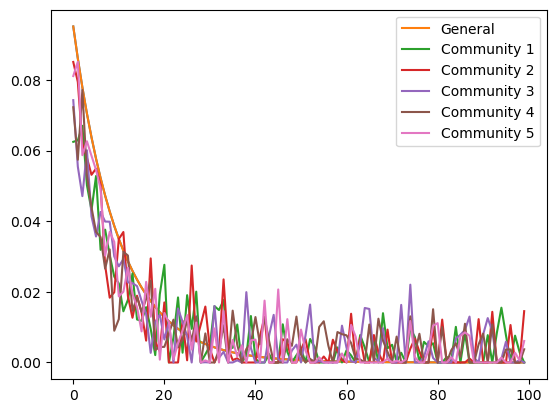

In [27]:
plt.plot(general.frequency)
import matplotlib.pyplot as plt

# plot general topic space
plt.plot(general.frequency, label='General')

# plot each community topic space
for i, community in enumerate(community_list):
    plt.plot(community.frequency, label=f'Community {i+1}')

# add legend and show plot
plt.legend()
plt.show()

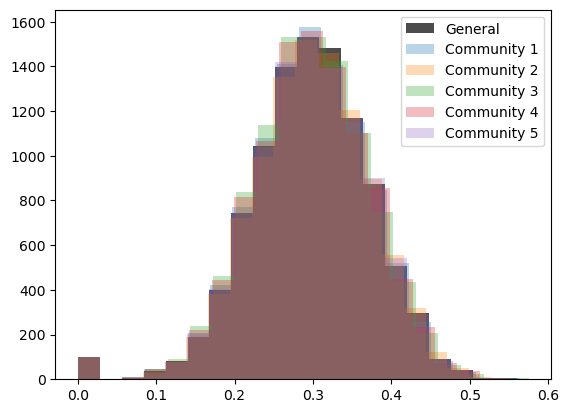

In [28]:
import matplotlib.pyplot as plt

plt.hist(general.weight.flatten(), bins=20, alpha=0.7, label='General', color='k')

# plot each community weight distribution
for i, community in enumerate(community_list):
    plt.hist(community.weight.flatten(), bins=20, alpha=0.3, label=f'Community {i+1}')

# add legend and show plot
plt.legend()
plt.show()


### 2. Event generation & Filter → Article generation

In [29]:
events = general.generate_events(event_num=100, event_topic_num=3)

In [30]:
# magnitude for each space
def get_magnitudes(topic_graph, events):
    event_num = events.shape[0]
    event_topic_num = events.shape[1]
    magnitudes = []
    for event in events:
        magnitudes.append(np.array([topic_graph.frequency[i] for i in event]).sum())
    return np.array(magnitudes)

# how to measure the relative strength of atricles according to magnitudes from both general and community topic graph
def event_generation(general, community_list, event_num, event_topic_num):
    
    events = general.generate_events(event_num=event_num, event_topic_num=event_topic_num)
    general_mag = get_magnitudes(general, events)
    mag_list = np.zeros((len(community_list), len(events)))
    for i in range(len(community_list)):
        mag_list[i] = get_magnitudes(community_list[i], events)
    
    return events, general_mag * mag_list

In [31]:
event_num = 100
event_topic_num = 3

events, articles = event_generation(general=general, community_list=community_list, event_num=event_num, event_topic_num=event_topic_num)

### 3. Activity generation

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_model(general, community_list, activity_graph_list):
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))

    # plot general topic space
    df = pd.DataFrame({'frequency': general.frequency})
    df.plot(kind='bar', ax=axs[0][0])
    axs[0][0].set_xticks(range(0, len(df), 5))
    axs[0][0].set_title('General')
    axs[0][0].set_xlabel('Topic')
    axs[0][0].set_ylabel('Frequency')

    # plot community 1 topic space
    df = pd.DataFrame({'frequency': community_list[0].frequency})
    df.plot(kind='bar', ax=axs[0][1])
    axs[0][1].set_xticks(range(0, len(df), 5))
    axs[0][1].set_title('Community 1')
    axs[0][1].set_xlabel('Topic')
    axs[0][1].set_ylabel('Frequency')

    # plot activity graph 1
    df = pd.DataFrame({'frequency': activity_graph_list[0][0]})
    df.plot(kind='bar', ax=axs[0][2])
    axs[0][2].set_xticks(range(0, len(df), 5))
    axs[0][2].set_title('Activity Graph 1')
    axs[0][2].set_xlabel('Event')
    axs[0][2].set_ylabel('Frequency')

    # plot general weight distribution
    axs[1][0].hist(general.weight.flatten(), bins=30)
    axs[1][0].set_title('General')
    axs[1][0].set_xlabel('Weight')
    axs[1][0].set_ylabel('Count')

    # plot community 1 weight distribution
    axs[1][1].hist(community_list[0].weight.flatten(), bins=30)
    axs[1][1].set_title('Community 1')
    axs[1][1].set_xlabel('Weight')
    axs[1][1].set_ylabel('Count')

    # plot activity graph 1 weight distribution
    axs[1][2].hist(activity_graph_list[0][1].flatten(), bins=30)
    axs[1][2].set_title('Activity Graph 1')
    axs[1][2].set_xlabel('Weight')
    axs[1][2].set_ylabel('Count')

    # show plot
    plt.show()

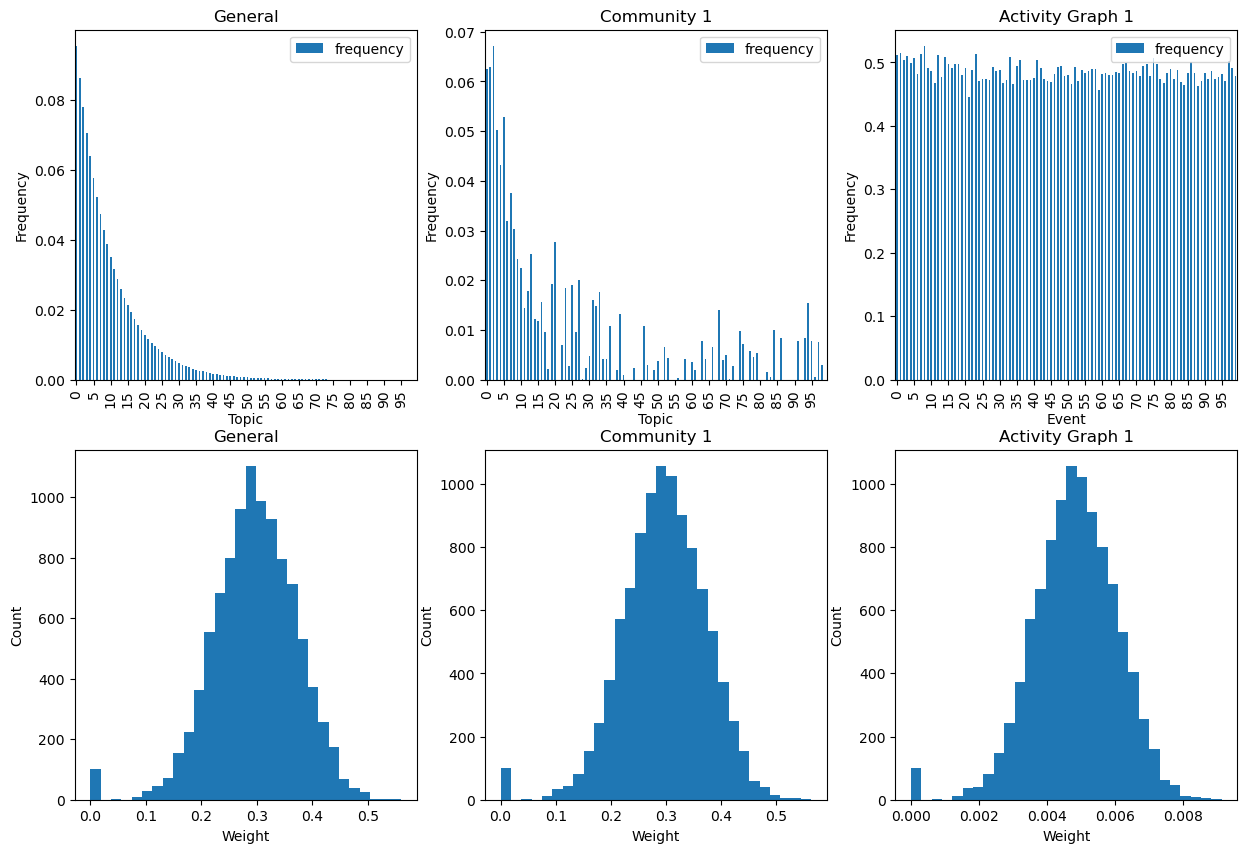

In [33]:
step_num = 100
modifier = 100
activity_graph_list = []
for i in range(len(community_list)):
    activity_graph_list.append(community_list[i].activity_generation(events=events, articles=articles[i], step_num=step_num, modifier=modifier))
    
plot_model(general, community_list, activity_graph_list)

In [21]:
np.sum(community_list[0].frequency), np.sum(community_list[i].frequency), np.sum(activity_graph_list[0][0])

(1.0, 1.0000000000000004, 0.8283503000335927)

In [ ]:
step_num = 1
modifier = 1
activity_graph_list = []
for i in range(len(community_list)):
    activity_graph_list.append(community_list[i].activity_generation(events=events, articles=articles[i], step_num=step_num, modifier=modifier))
    
plot_model(general, community_list, activity_graph_list)

In [ ]:
A = np.array([[0, 0.5, 2, 1],
              [0.5, 0, 1, 0],
              [2, 1, 0, 0.5],
              [1, 0, 0.5, 0]])
P = A / np.sum(A, axis=1, keepdims=True)
I = np.eye(4)
S = 5
V = [2, 1, 4, 3]

E_visits = (sum([np.linalg.matrix_power(P, i).T for i in range(S+1)])).dot(V)  # including first visits (intial V)
E_passes = P * ((sum([np.linalg.matrix_power(P, i).T for i in range(S)])).dot(V))[:, np.newaxis]

In [ ]:
A = community_list[0].weight
P = A / np.sum(A, axis=1, keepdims=True)
I = np.eye(len(A))

In [ ]:
sum([np.linalg.matrix_power(P.T, i) for i in range(S)]).dot(I-P.T)

In [ ]:
I-np.linalg.matrix_power(P.T, S)

In [ ]:
plt.imshow(A)

### 4. Topic embeddings / frequency change

### 5. Main

In [ ]:
dim = 16
topic_num = 100
std = 0.1
comm_num = 5
event_num = 1000
event_topic_num = 3
step_num = 10
timestep = 20


general, community_list = generate_topic_spaces(dim=dim, topic_num=topic_num, comm_num=comm_num, std=std)
activity_graph_list = []
for t in tqdm(range(timestep)):
    events, event_filter = event_generation(general=general, community_list=community_list, event_num=event_num, event_topic_num=event_topic_num, prob_func=myprob)
    activity_graph_list.append([])

    for i, community in enumerate(community_list):
        events_eff = events[event_filter[i].nonzero()[0]]
        activity_graph_list[-1].append(community.activity_generation(events=events_eff, step_num=step_num))

In [ ]:
# magnitude 곱해서 article_num 대신 article_ratio로 결정, 외부의 event가 얼마나 많은 article로 표현되는지 계수로 표현
# random walk는 event마다 한번씩, 이 article의 강도를 곱해서 전체 normalize 된 trajectory activity graph를 구성
# max norm 대신 양쪽에서 각각 Max norm을 한 값을 평균해서 정하기 (아니면 강한 쪽을 좀 더 강하게 하기?)


### 6. etc

In [ ]:
import numpy as np

def random_walk_expectation(A, V, S):
    N = len(A)
    result = np.zeros(N)
    edge_counts = np.zeros((N, N))
    result += V
    for _ in range(S):
        new_V = np.zeros(N)
        for i in range(N):
            neighbors = np.nonzero(A[i])[0]
            if len(neighbors) > 0:
                weights = A[i][neighbors]
                weights /= np.sum(weights)
                choices = np.random.choice(neighbors, size=int(V[i]), p=weights)
                for choice in choices:
                    new_V[choice] += 1
                    edge_counts[i, choice] += 1
        V = new_V
        result += V

    return result, edge_counts

# Example usage:
N = 4  # Number of nodes
A = np.array([[0, 2, 1, 1],
              [2, 0, 3, 0],
              [1, 3, 0, 1],
              [1, 0, 1, 0.]])  # Adjacency matrix
P = A / A.sum(axis=1, keepdims=True)
V = np.array([2, 3, 4, 1])  # Initial number of walks on each node
#V = sum(A) / np.sum(A) * 16
S = 10 # Number of steps for each walker

E_visits_list = []
E_passes_list = []
for i in range(100000):
    E_visits, E_passes = random_walk_expectation(A, V, S)
    
    E_visits_list.append(E_visits)
    E_passes_list.append(E_passes)
    
E_visits = np.mean(E_visits_list, axis=0)
E_passes = np.mean(E_passes_list, axis=0)

print("Expectation values for visits of each node:")
print(E_visits)

print("Expectation values for passes of each link:")
print(E_passes)

print((sum([np.linalg.matrix_power(P, i).T for i in range(S+1)])).dot(V))
print(P * ((sum([np.linalg.matrix_power(P, i).T for i in range(S)])).dot(V))[:, np.newaxis])

In [ ]:
# get eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(P.T)
W = np.real(eigvecs[:, 0].T.dot(eigvecs[:, 0].conjugate()))

(I-np.linalg.matrix_power(P.T, S) + S*W).dot(np.linalg.inv(I-P.T+W))
sum([np.linalg.matrix_power(P.T, i) for i in range(S)])